# Merging Colombia

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df_dengue = pd.read_csv('silver/dengue_no_split.csv')
df_dengue.head()

,SEMANA,ANO,Casos,DATE
0,1,2007,315,2007-01-01
1,2,2007,236,2007-01-08
2,3,2007,252,2007-01-15
3,4,2007,305,2007-01-22
4,5,2007,360,2007-01-29


In [49]:
df_zika = pd.read_csv('silver/zika.csv')
df_zika.drop(columns=['Unnamed: 0'], inplace=True)
df_zika.head()

,SEMANA,ANO,Casos,DATE
0,32,2015,26,2015-08-03
1,33,2015,23,2015-08-10
2,34,2015,14,2015-08-17
3,35,2015,6,2015-08-24
4,36,2015,9,2015-08-31


In [50]:
df_chic = pd.read_csv('silver/chicunguya.csv')
df_chic.drop(columns=['Unnamed: 0'], inplace=True)
df_chic.head()

,SEMANA,ANO,Casos,DATE
0,23,2014,13,2014-06-02
1,24,2014,10,2014-06-09
2,25,2014,8,2014-06-16
3,26,2014,6,2014-06-23
4,27,2014,8,2014-06-30


In [51]:
df_var = pd.read_csv('silver/varicela.csv')
df_var.head()

,SEMANA,ANO,Casos,DATE
0,1,2007,250,2007-01-01
1,2,2007,307,2007-01-08
2,3,2007,301,2007-01-15
3,4,2007,266,2007-01-22
4,5,2007,357,2007-01-29


In [52]:
# meteo
df_meteo = pd.read_csv('silver/meteo_colombia.csv')
df_meteo.head()

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres
0,2019-12-30,19.450377,13.011834,26.319135,2.226111,194.431169,9.722817,1016.109736
1,2020-01-06,19.083392,11.511172,26.336976,1.757209,119.680480,11.313645,1014.248141
2,2020-01-13,20.013624,14.086101,26.512647,1.824270,70.500326,12.548239,1012.854773
3,2020-01-20,19.412924,14.504582,25.324612,2.991630,218.793642,9.854209,1015.718609
4,2020-01-27,19.669235,13.603087,25.948477,2.780497,143.062092,10.089568,1015.457101


In [53]:
# mobility
df_mob = pd.read_csv('silver/mobility_index.csv')
df_mob = df_mob[df_mob['country'] == 'COL']
df_mob.head()

,Date,Mean_distance_avg_14day_movavg,country
1624,2020-03-24,9.21,COL
1625,2020-03-25,8.63,COL
1626,2020-03-26,7.97,COL
1627,2020-03-27,6.91,COL
1628,2020-03-28,6.42,COL


In [54]:
# google
df_google = pd.read_csv('silver/google_trends.csv')
df_google = df_google[df_google['country'] == 'COL']
df_google.drop(columns=['country'], inplace = True)
df_google.head()

,week,google_physician,google_hospital,google_pharmacy,google_symptom
420,2019-12-23,23,7,4,21
421,2019-12-30,32,9,4,26
422,2020-01-06,34,8,4,25
423,2020-01-13,36,9,4,29
424,2020-01-20,34,11,4,33


In [55]:
# atmospheric data
df_atmos = pd.read_csv('silver/atmosferic_data.csv')
df_atmos.head()

,Date,Country,Specie,median
0,2022-03-28,BR,co,2.266667
1,2022-03-28,BR,dew,20.000000
2,2022-03-28,BR,humidity,81.000000
3,2022-03-28,BR,no2,6.066667
4,2022-03-28,BR,o3,15.866667


In [56]:
df_atmos = df_atmos[df_atmos['Country'] == 'CO']
df_atmos = df_atmos[['Date', 'Specie', 'median']]
df_atmos

,Date,Specie,median
5942,2014-12-29,co,5.10
5943,2014-12-29,no2,6.50
5944,2014-12-29,o3,4.20
5945,2014-12-29,pm10,29.00
5946,2014-12-29,pm25,50.00
...,...,...,...
236634,2023-12-31,pressure,1027.75
236635,2023-12-31,so2,0.50
236636,2023-12-31,temperature,15.30
236637,2023-12-31,wd,244.00


In [57]:
df_atmos_wide = df_atmos.pivot_table(index ='Date', columns='Specie', values='median').reset_index()
df_atmos_wide.head()

Specie,Date,co,dew,humidity,no2,o3,pm10,pm25,precipitation,pressure,so2,temperature,uvi,wd,wind gust,wind speed,wind-gust,wind-speed
0,2014-12-29,5.1,NaN,NaN,6.5,4.2,29.0,50.0,NaN,NaN,0.8,NaN,-1.0,NaN,NaN,NaN,NaN,NaN
1,2014-12-30,5.4,NaN,NaN,6.1,3.2,30.0,51.0,NaN,NaN,0.7,NaN,-1.0,NaN,NaN,NaN,NaN,NaN
2,2014-12-31,5.2,NaN,NaN,4.4,4.9,21.0,30.0,NaN,NaN,0.6,NaN,-1.0,NaN,NaN,NaN,NaN,NaN
3,2015-01-01,4.7,NaN,NaN,4.2,6.3,27.0,55.0,NaN,NaN,0.7,NaN,-1.0,NaN,NaN,NaN,NaN,NaN
4,2015-01-02,4.5,NaN,NaN,4.2,6.2,24.0,38.0,NaN,NaN,0.5,NaN,-1.0,NaN,NaN,NaN,NaN,NaN


In [58]:
df_atmos_wide = df_atmos_wide[df_atmos_wide['Date'] >= '2019-12-31']
df_atmos_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1378 entries, 1110 to 2487
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1378 non-null   object 
 1   co             1377 non-null   float64
 2   dew            1358 non-null   float64
 3   humidity       1367 non-null   float64
 4   no2            1377 non-null   float64
 5   o3             1377 non-null   float64
 6   pm10           1377 non-null   float64
 7   pm25           1378 non-null   float64
 8   precipitation  1046 non-null   float64
 9   pressure       1367 non-null   float64
 10  so2            1370 non-null   float64
 11  temperature    1367 non-null   float64
 12  uvi            0 non-null      float64
 13  wd             1326 non-null   float64
 14  wind gust      69 non-null     float64
 15  wind speed     80 non-null     float64
 16  wind-gust      1093 non-null   float64
 17  wind-speed     1292 non-null   float64
dtypes: float64

In [59]:
df_atmos_wide.columns

Index(['Date', 'co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25',
       'precipitation', 'pressure', 'so2', 'temperature', 'uvi', 'wd',
       'wind gust', 'wind speed', 'wind-gust', 'wind-speed'],
      dtype='object', name='Specie')

In [60]:
df_atmos_s = df_atmos_wide[['Date', 'co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']].copy()
df_atmos_s

Specie,Date,co,dew,humidity,no2,o3,pm10,pm25,so2
1110,2019-12-31,9.40,NaN,97.00,10.40,4.85,27.5,56.0,0.7
1111,2020-01-01,9.90,NaN,97.00,5.95,5.25,29.5,67.5,0.6
1112,2020-01-02,8.55,11.00,81.20,7.85,6.10,24.0,52.0,0.6
1113,2020-01-03,10.45,11.50,82.05,9.70,6.70,28.5,58.0,0.6
1114,2020-01-04,10.05,10.75,80.95,12.00,7.95,36.0,64.5,1.1
...,...,...,...,...,...,...,...,...,...
2483,2023-12-27,14.20,12.00,84.50,15.95,3.90,34.0,59.0,0.9
2484,2023-12-28,13.05,14.00,86.00,14.40,2.30,28.0,63.0,0.6
2485,2023-12-29,11.90,13.00,85.50,14.60,4.05,32.0,66.5,0.8
2486,2023-12-30,11.60,14.00,81.50,12.10,4.25,28.0,60.5,0.7


In [61]:
df_atmos_s['Date'] = pd.to_datetime(df_atmos_s['Date'])

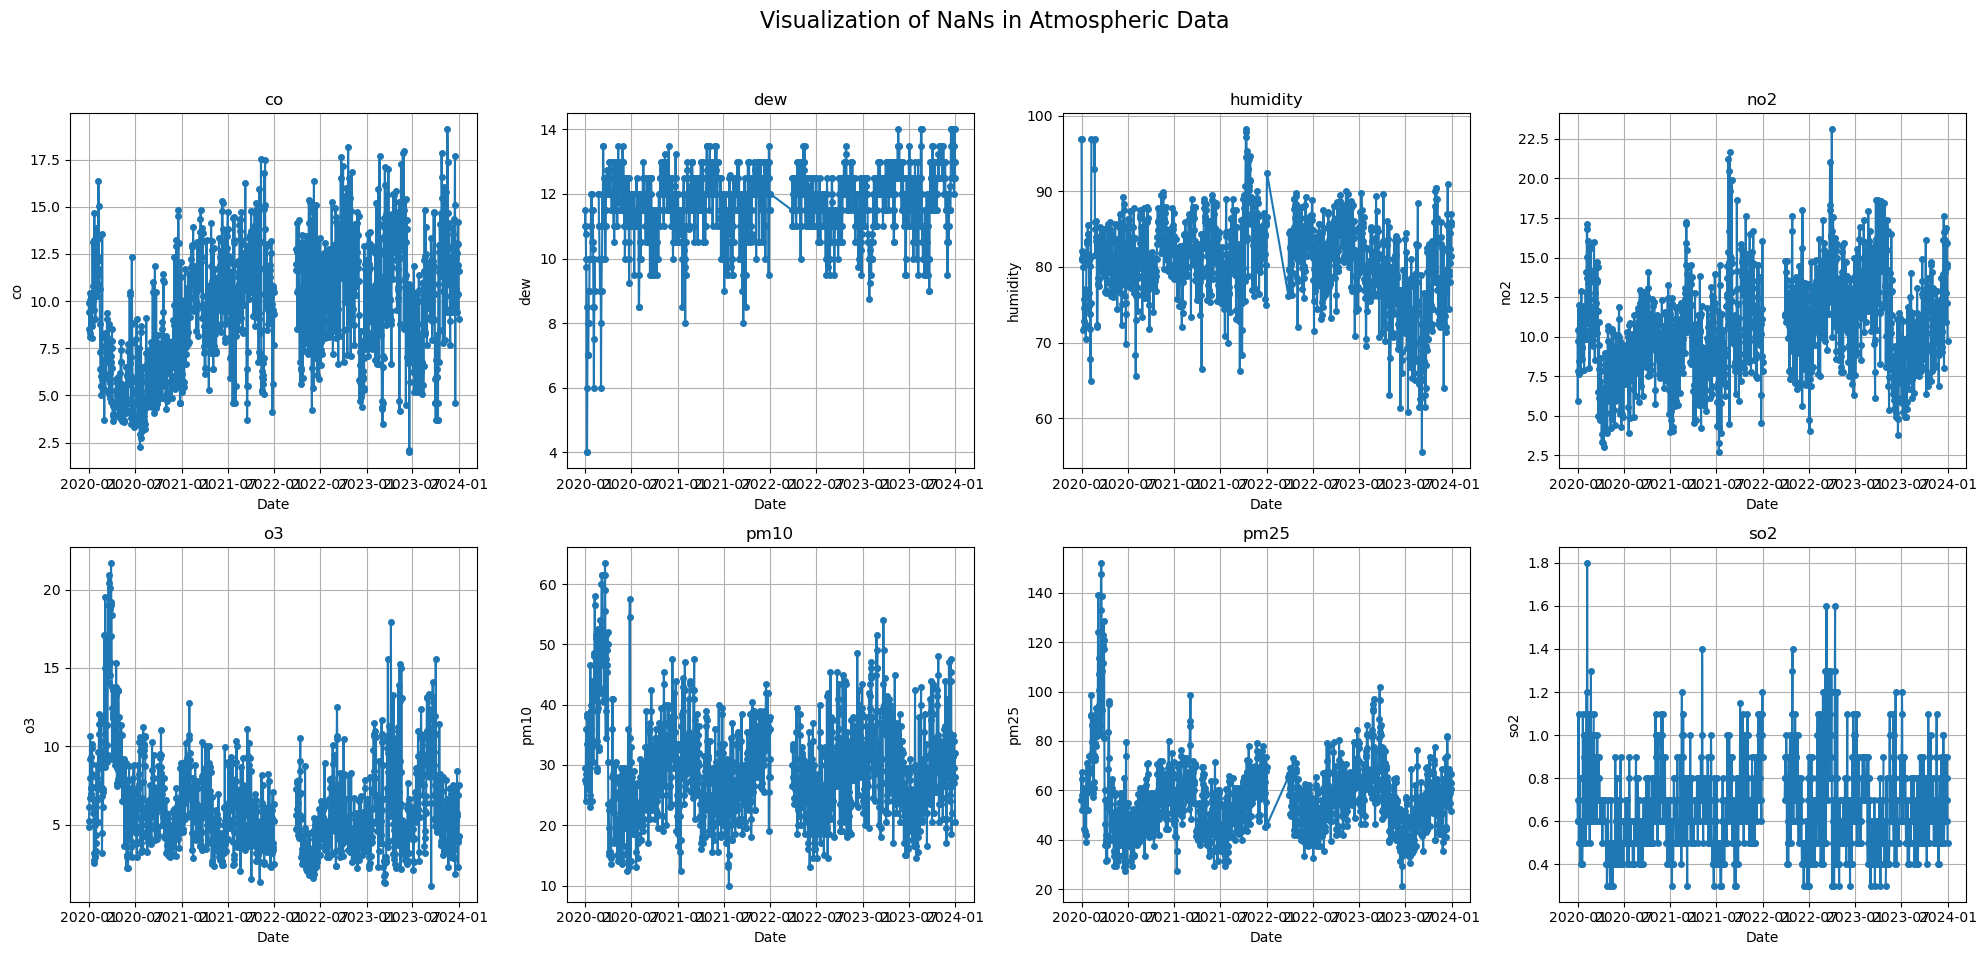

In [62]:
import matplotlib.pyplot as plt

# Ensure 'Date' is datetime for proper plotting
df_atmos_s['Date'] = pd.to_datetime(df_atmos_s['Date'])

# Set up a 2x4 grid of plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Plot each column against the Date
for i, col in enumerate(df_atmos_s.columns[1:]):  # Skip 'Date'
    axes[i].plot(df_atmos_s['Date'], df_atmos_s[col], marker='o', linestyle='-', markersize=4)
    axes[i].set_title(col)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(col)
    axes[i].grid(True)

# Adjust layout and add main title
fig.suptitle('Visualization of NaNs in Atmospheric Data', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

# Display the plot
plt.show()

The nans are in the 2022 period. Lets fill them with interpolation

In [63]:
for col in df_atmos_s.columns[1:]:  # Skip 'Date'
    df_atmos_s[col] = df_atmos_s[col].interpolate(method='linear')
    df_atmos_s[col] = df_atmos_s[col].bfill().ffill()

# Verify that there are no remaining NaNs
print(df_atmos_s.isna().sum())

Specie
Date        0
co          0
dew         0
humidity    0
no2         0
o3          0
pm10        0
pm25        0
so2         0
dtype: int64


In [64]:
df_atmos_s.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1378 entries, 1110 to 2487
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1378 non-null   datetime64[ns]
 1   co        1378 non-null   float64       
 2   dew       1378 non-null   float64       
 3   humidity  1378 non-null   float64       
 4   no2       1378 non-null   float64       
 5   o3        1378 non-null   float64       
 6   pm10      1378 non-null   float64       
 7   pm25      1378 non-null   float64       
 8   so2       1378 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 107.7 KB


# Wrangle

### Dates

In [65]:
df_dengue['date'] = pd.to_datetime(df_dengue['DATE'])
df_zika['date'] = pd.to_datetime(df_zika['DATE'])
df_chic['date'] = pd.to_datetime(df_chic['DATE'])
df_var['date'] = pd.to_datetime(df_var['DATE'])
df_meteo['date'] = pd.to_datetime(df_meteo['date'])
df_mob['date'] = pd.to_datetime(df_mob['Date'])
df_google['date'] = pd.to_datetime(df_google['week'])
df_atmos_s['date'] = pd.to_datetime(df_atmos_s['Date'])

In [66]:
# get the week
df_dengue['week'] = df_dengue['date'].dt.to_period('W').dt.to_timestamp()
df_zika['week'] = df_zika['date'].dt.to_period('W').dt.to_timestamp()
df_chic['week'] = df_chic['date'].dt.to_period('W').dt.to_timestamp()
df_var['week'] = df_var['date'].dt.to_period('W').dt.to_timestamp()

In [67]:
df_meteo['week'] = df_meteo['date'].dt.to_period('W').dt.to_timestamp()

In [68]:
df_google['week'] = df_google['date'].dt.to_period('W').dt.to_timestamp()
df_google.drop(columns=['date'], inplace = True)

### Rename columns

In [69]:
df_dengue.rename(columns={'Casos':'dengue'}, inplace=True)
df_zika.rename(columns={'Casos':'zika'}, inplace=True)
df_chic.rename(columns={'Casos':'chik'}, inplace=True)
df_var.rename(columns={'Casos':'var'}, inplace=True)
df_mob.rename(columns={'Mean_distance_avg_14day_movavg':'mob_index'}, inplace=True)


### Mobilty to weekly

In [70]:
df_mob['week'] = df_mob['date'].dt.to_period('W').dt.to_timestamp()
df_mob_w = df_mob.groupby('week')[['mob_index']].mean().reset_index()
#df_mob_w.rename(columns={'week':'date'}, inplace=True)
df_mob_w

,week,mob_index
0,2020-03-23,7.531667
1,2020-03-30,4.344286
2,2020-04-06,2.705714
3,2020-04-13,1.977143
4,2020-04-20,2.207143
...,...,...
228,2024-08-05,24.570000
229,2024-08-12,49.780000
230,2024-08-19,53.945714
231,2024-08-26,26.255714


### Atmospheric to weekly

In [72]:
df_atmos_s['week'] = df_atmos_s['date'].dt.to_period('W').dt.to_timestamp()
df_atmos_s.drop(columns=['Date', 'date'], inplace=True)
df_atmos_week = df_atmos_s.groupby('week')[['co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']].mean().reset_index()
df_atmos_week

Specie,week,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2019-12-30,9.408333,11.041667,86.700000,9.058333,6.916667,28.750000,59.250000,0.683333
1,2020-01-06,9.328571,7.178571,75.514286,9.807143,8.450000,33.142857,56.785714,0.614286
2,2020-01-13,10.192857,8.000000,74.542857,10.057143,7.221429,31.428571,47.000000,0.471429
3,2020-01-20,12.250000,10.428571,83.364286,10.550000,3.528571,36.285714,59.571429,0.800000
4,2020-01-27,12.171429,11.214286,80.242857,10.985714,5.942857,37.857143,66.571429,0.757143
...,...,...,...,...,...,...,...,...,...
192,2023-11-27,10.857143,10.928571,73.971429,10.464286,5.121429,30.714286,52.785714,0.628571
193,2023-12-04,11.550000,11.392857,75.278571,11.128571,5.564286,32.642857,55.214286,0.628571
194,2023-12-11,12.235714,12.642857,80.657143,12.878571,4.500000,34.357143,63.000000,0.742857
195,2023-12-18,12.050000,13.142857,79.214286,15.557143,6.064286,29.714286,61.642857,0.714286


# Merge

In [73]:
df_merge0 = df_dengue[['week', 'dengue']].merge(df_zika[['week', 'zika']], how='outer', on='week' )
df_merge1 = df_merge0.merge(df_chic[['week', 'chik']], how='outer', on='week')
df_merge2 = df_merge1.merge(df_var[['week', 'var']], how='outer', on='week')
df_merge3 = df_merge2.merge(df_meteo,how='inner', on='week')
df_merge4 = df_merge3.merge(df_mob_w, how='inner', on='week')
df_merge5 = df_merge4.merge(df_google, how = 'inner', on='week')
df_merge6 = df_merge5.merge(df_atmos_week, how='left', on='week')
df_merge6

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,NaN,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,2023-11-27,3118,NaN,1.0,459.0,2023-11-27,19.216266,12.896204,25.435018,0.714470,...,6,24,10.857143,10.928571,73.971429,10.464286,5.121429,30.714286,52.785714,0.628571
193,2023-12-04,3369,NaN,1.0,388.0,2023-12-04,19.273944,13.558017,25.321583,1.902538,...,5,26,11.550000,11.392857,75.278571,11.128571,5.564286,32.642857,55.214286,0.628571
194,2023-12-11,3446,1.0,1.0,430.0,2023-12-11,19.493746,14.694348,25.424447,4.540202,...,4,24,12.235714,12.642857,80.657143,12.878571,4.500000,34.357143,63.000000,0.742857
195,2023-12-18,3312,2.0,2.0,344.0,2023-12-18,19.810996,14.662213,25.917042,3.151673,...,5,25,12.050000,13.142857,79.214286,15.557143,6.064286,29.714286,61.642857,0.714286


In [75]:
df_final = df_merge6.copy()

In [76]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   week              197 non-null    datetime64[ns]
 1   dengue            197 non-null    int64         
 2   zika              108 non-null    float64       
 3   chik              133 non-null    float64       
 4   var               197 non-null    float64       
 5   date              197 non-null    datetime64[ns]
 6   tavg              197 non-null    float64       
 7   tmin              197 non-null    float64       
 8   tmax              197 non-null    float64       
 9   prcp              197 non-null    float64       
 10  wdir              197 non-null    float64       
 11  wspd              197 non-null    float64       
 12  pres              197 non-null    float64       
 13  mob_index         197 non-null    float64       
 14  google_physician  197 non-

Chikungunya and Zika have null values, check it out

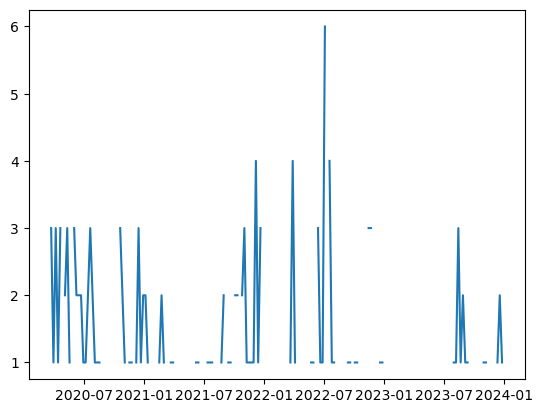

In [77]:
plt.plot(df_final['week'], df_final['zika'])

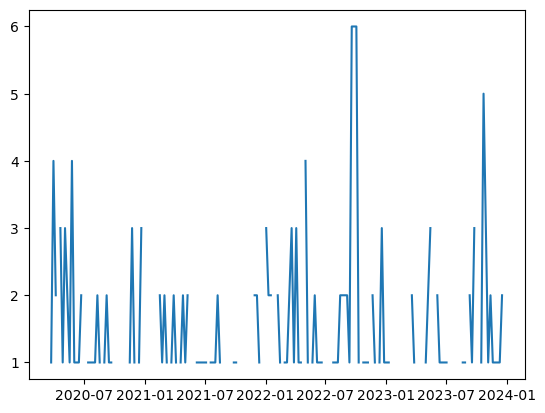

In [78]:
plt.plot(df_final['week'], df_final['chik'])

The null values are almost 100% sure to be 0 / there are few contagions because is eradicated, so there are no reported cases for those dates

In [79]:
df_final['chik'] = df_final['chik'].fillna(0)
df_final['zika'] = df_final['zika'].fillna(0)

In [80]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   week              197 non-null    datetime64[ns]
 1   dengue            197 non-null    int64         
 2   zika              197 non-null    float64       
 3   chik              197 non-null    float64       
 4   var               197 non-null    float64       
 5   date              197 non-null    datetime64[ns]
 6   tavg              197 non-null    float64       
 7   tmin              197 non-null    float64       
 8   tmax              197 non-null    float64       
 9   prcp              197 non-null    float64       
 10  wdir              197 non-null    float64       
 11  wspd              197 non-null    float64       
 12  pres              197 non-null    float64       
 13  mob_index         197 non-null    float64       
 14  google_physician  197 non-

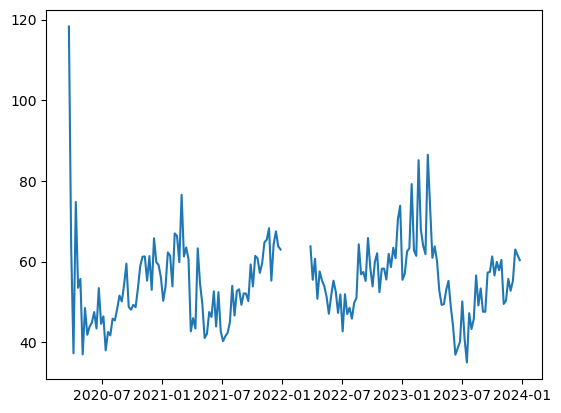

In [81]:
plt.plot(df_final['week'], df_final['pm25'])

Atmospheric have nans because they have not the info, fill them with interpolation

In [82]:
df_final.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [83]:
cols_to_fill = ['co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']
for col in cols_to_fill:
    df_final[col] = df_final[col].interpolate(method='linear')
    df_final[col] = df_final[col].bfill().ffill()

# Verify that there are no remaining NaNs
print(df_final.isna().sum())

week                0
dengue              0
zika                0
chik                0
var                 0
date                0
tavg                0
tmin                0
tmax                0
prcp                0
wdir                0
wspd                0
pres                0
mob_index           0
google_physician    0
google_hospital     0
google_pharmacy     0
google_symptom      0
co                  0
dew                 0
humidity            0
no2                 0
o3                  0
pm10                0
pm25                0
so2                 0
dtype: int64


In [84]:
df_final.to_csv('gold/epidemics.csv', index = False)